<a href="https://colab.research.google.com/github/FernandaFranco/mvp-sprint-qualidade-seguranca-sistemas-inteligentes/blob/main/MVP_Qualidade_Software_Seguranca_Sistemas_Inteligentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação: Engajamento de Jogadores Online

O objetivo deste projeto é treinar e comparar modelos de classificação para prever o nível de engajamento de jogadores online (High, Medium ou Low), como parte do MVP da pós-graduação em Engenharia de Software da PUC-Rio.

O dataset utilizado é o [Predict Online Gaming Behavior Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset), disponível no Kaggle. Ele contém dados demográficos (idade, gênero, localização) e métricas de jogo (tempo de jogo, frequência de sessões, nível do jogador, conquistas desbloqueadas, entre outras).

A variável alvo é a coluna `EngagementLevel`, que representa o nível de engajamento do jogador. Serão utilizados os 4 algoritmos obrigatórios para este MVP: KNN, Árvore de Classificação, Naive Bayes e SVM.

## Carga dos dados

Para garantir reprodutibilidade e permitir que qualquer pessoa execute o notebook sem configuração adicional, o dataset é carregado diretamente via URL a partir de um repositório no GitHub.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/FernandaFranco/Gaming-Behavior/main/online_gaming_behavior_dataset.csv")
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


## Análise Exploratória dos Dados (EDA)

Antes de qualquer modelagem, é fundamental entender a estrutura e características do dataset. As células a seguir exploram o tamanho do dataset, tipos de dados, distribuição do target e estatísticas descritivas das features numéricas.

In [3]:
df.shape


(40034, 13)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [5]:
df['EngagementLevel'].value_counts()

,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


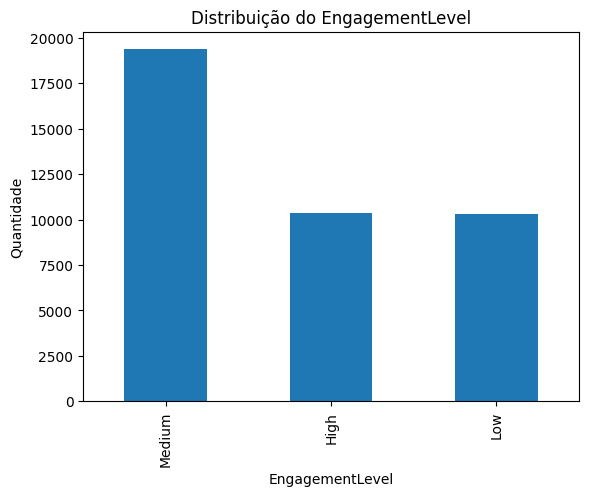

In [6]:
df['EngagementLevel'].value_counts().plot(kind='bar')
plt.title('Distribuição do EngagementLevel')
plt.ylabel('Quantidade')
plt.show()


In [7]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


### Resumo da Análise Exploratória

O dataset possui 40.034 registros e 13 colunas, sem valores faltantes em nenhuma delas. Das 13 colunas, 7 são numéricas, 4 são categóricas, 1 é o target (`EngagementLevel`) e 1 é um identificador (`PlayerID`) que não será utilizado como feature.

O target apresenta um leve desbalanceamento: a classe Medium representa aproximadamente 48% dos registros, enquanto High e Low representam cerca de 26% cada. Isso significa que um modelo que simplesmente chutasse sempre "Medium" teria ~48% de acurácia — qualquer modelo precisa superar esse baseline para demonstrar que aprendeu algo significativo.

## Pré-Processamento

Nesta etapa, os dados serão preparados para alimentar os modelos de classificação. Isso envolve remover colunas irrelevantes, converter variáveis categóricas em numéricas e normalizar as features.

### Remoção do identificador

A coluna `PlayerID` é apenas um número sequencial que identifica cada jogador. Ela não tem nenhuma relação com o nível de engajamento e, se fosse mantida, poderia introduzir padrões falsos no modelo. Por isso, será removida.

In [8]:
df = df.drop('PlayerID', axis=1)

### Transformação das variáveis categóricas

Modelos de machine learning trabalham com números, então as variáveis categóricas precisam ser convertidas. A técnica de conversão depende da natureza da variável:

**Label Encoding** para variáveis ordinais ou binárias:
- `Gender` (Male/Female) — variável binária, pode ser convertida em 0 e 1
- `GameDifficulty` (Easy/Medium/Hard) — tem ordem natural (Easy < Medium < Hard), então faz sentido representar como 0, 1 e 2

**One-Hot Encoding** para variáveis nominais (sem ordem natural):
- `Location` (USA, Europe, Asia, Other) — não há hierarquia entre localizações
- `GameGenre` (Action, RPG, Simulation, Sports, Strategy) — não há ordem entre gêneros de jogo

In [9]:
print(df['Gender'].unique())
print(df['Location'].unique())
print(df['GameGenre'].unique())
print(df['GameDifficulty'].unique())

['Male' 'Female']
['Other' 'USA' 'Europe' 'Asia']
['Strategy' 'Sports' 'Action' 'RPG' 'Simulation']
['Medium' 'Easy' 'Hard']


In [10]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['GameDifficulty'] = df['GameDifficulty'].map({'Easy': 0, 'Medium': 1, 'Hard': 2})
df = pd.get_dummies(df, columns=['Location'], dtype=int)
df = pd.get_dummies(df, columns=['GameGenre'], dtype=int)
df.head()

,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,1,6,108,79,25,Medium,0,0,1,0,0,0,0,0,1
1,29,0,5.525961,0,1,5,144,11,10,Medium,0,0,0,1,0,0,0,0,1
2,22,0,8.223755,0,0,16,142,35,41,High,0,0,0,1,0,0,0,1,0
3,35,1,5.265351,1,0,9,85,57,47,Medium,0,0,0,1,1,0,0,0,0
4,33,1,15.531945,0,1,2,131,95,37,Medium,0,1,0,0,1,0,0,0,0


### Separação de features e target

Antes de treinar os modelos, é necessário separar as features (variáveis independentes) do target (variável que queremos prever). Por convenção, `X` (maiúsculo) representa a matriz de features e `y` (minúsculo) representa o vetor do target.

In [11]:
X = df.drop('EngagementLevel', axis=1)
y = df['EngagementLevel']

### Separação treino/teste (holdout)

O dataset é dividido em 80% para treino e 20% para teste. O parâmetro `random_state=42` garante que a divisão seja sempre a mesma em diferentes execuções, assegurando a reprodutibilidade dos resultados.

In [12]:
seed = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=seed, stratify=y
)

print("Treino:", X_train.shape)
print("Teste: ", X_test.shape)


Treino: (32027, 18)
Teste:  (8007, 18)


## Avaliação Inicial com Cross-Validation

Antes de otimizar hiperparâmetros, avaliamos todos os modelos com `cross_val_score` usando `StratifiedKFold` com 10 partições. Cada modelo é encapsulado em um `Pipeline` com `StandardScaler`, mantendo a mesma configuração usada no GridSearchCV e evitando data leakage. Isso dá uma estimativa robusta do desempenho de cada algoritmo nos dados de treino, mantendo a proporção das classes em cada fold.

O boxplot permite comparar visualmente a distribuição de acurácia entre os modelos e identificar quais têm melhor desempenho e menor variância antes de investir na otimização.


KNN: 0.705 (0.008)
CART: 0.832 (0.007)
NB: 0.840 (0.005)
SVM: 0.884 (0.004)


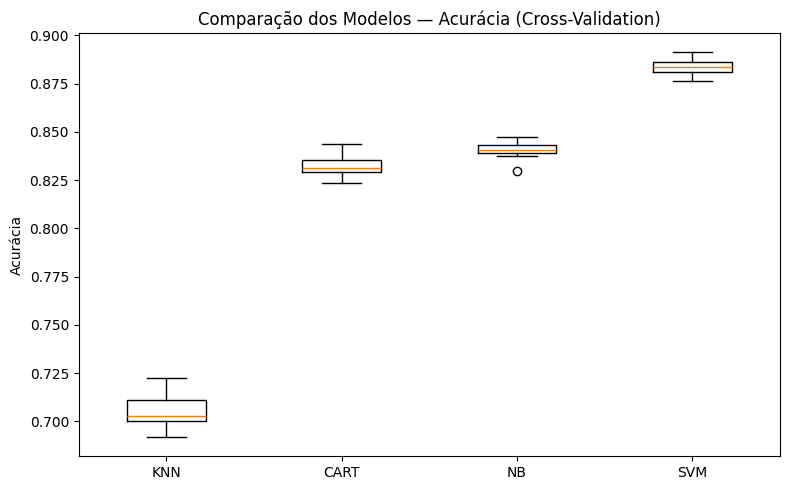

In [13]:
np.random.seed(42)

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = "accuracy"

models = [
    ("KNN",   KNeighborsClassifier()),
    ("CART",  DecisionTreeClassifier()),
    ("NB",    GaussianNB()),
    ("SVM",   SVC()),
]

results = []
names = []
cv_scores = {}

for name, model in models:
    pipe = Pipeline([("StandardScaler", StandardScaler()), (name, model)])
    cv_results = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    cv_scores[name] = cv_results.mean()
    print(f"{name}: {cv_results.mean():.3f} ({cv_results.std():.3f})")

# Aliases para compatibilidade com a tabela comparativa
acc_knn = cv_scores["KNN"]
acc_dtc = cv_scores["CART"]
acc_nb  = cv_scores["NB"]
acc_svc = cv_scores["SVM"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(results, labels=names)
ax.set_title("Comparação dos Modelos — Acurácia (Cross-Validation)")
ax.set_ylabel("Acurácia")
plt.tight_layout()
plt.show()


O boxplot acima mostra a distribuição de acurácia de cada modelo ao longo dos 10 folds. Modelos com mediana mais alta e caixa mais estreita são preferíveis, pois indicam bom desempenho e estabilidade. Esses resultados servem como baseline para comparar o impacto da otimização de hiperparâmetros na próxima etapa.


## Otimização de Hiperparâmetros

Até agora, todos os modelos foram avaliados com parâmetros padrão via cross-validation. A otimização utiliza `GridSearchCV` para encontrar a melhor combinação de hiperparâmetros, usando cross-validation com 5 folds.

Cada modelo é encapsulado em um `Pipeline` com `StandardScaler`, garantindo que a normalização seja aplicada corretamente em cada fold — evitando data leakage. O `StandardScaler` padroniza as features para média 0 e desvio padrão 1, o que é especialmente importante para KNN e SVM, que são sensíveis à escala das features.


### KNN

Testamos diferentes valores de `n_neighbors` (ímpares, para evitar empate na votação): 3, 5, 7, 9 e 11.

In [14]:
np.random.seed(42)

param_grid = {'KNN__n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = GridSearchCV(
    Pipeline([('StandardScaler', StandardScaler()), ('KNN', KNeighborsClassifier())]),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_knn.fit(X_train, y_train)
print("KNN — melhor parâmetro:", grid_knn.best_params_)
print("KNN — melhor score CV:  ", round(grid_knn.best_score_, 4))


KNN — melhor parâmetro: {'KNN__n_neighbors': 11}
KNN — melhor score CV:   0.7281


### Árvore de Classificação

Testamos diferentes valores de `max_depth` (profundidade máxima da árvore) e `min_samples_split` (quantidade mínima de amostras para dividir um nó). Limitar esses parâmetros ajuda a evitar overfitting.

In [15]:
param_grid = {
    'CART__max_depth': [3, 5, 10, 20, None],
    'CART__min_samples_split': [2, 5, 10]
}

grid_dtc = GridSearchCV(
    Pipeline([('StandardScaler', StandardScaler()), ('CART', DecisionTreeClassifier())]),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_dtc.fit(X_train, y_train)
print("Árvore — melhor parâmetro:", grid_dtc.best_params_)
print("Árvore — melhor score CV:  ", round(grid_dtc.best_score_, 4))


Árvore — melhor parâmetro: {'CART__max_depth': 10, 'CART__min_samples_split': 10}
Árvore — melhor score CV:   0.8971


### Naive Bayes

Testamos diferentes valores de `var_smoothing`, um parâmetro de suavização que evita probabilidades zero no cálculo.

In [16]:
param_grid = {'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

grid_gnb = GridSearchCV(
    Pipeline([('StandardScaler', StandardScaler()), ('NB', GaussianNB())]),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_gnb.fit(X_train, y_train)
print("NB — melhor parâmetro:", grid_gnb.best_params_)
print("NB — melhor score CV:  ", round(grid_gnb.best_score_, 4))


NB — melhor parâmetro: {'NB__var_smoothing': 1e-09}
NB — melhor score CV:   0.8394


O melhor `var_smoothing` encontrado foi o valor padrão (1e-9). A otimização confirmou que o Naive Bayes já estava na melhor configuração possível dentro dos parâmetros testados.

### SVM

Testamos diferentes kernels (`rbf` para fronteiras curvas, `linear` para fronteiras retas) e valores de `C` (parâmetro de regularização — valores altos tentam acertar todos os pontos, valores baixos aceitam alguns erros para generalizar melhor). Obs: esta etapa é significativamente mais demorada devido à complexidade computacional do SVM com 40 mil registros.

In [17]:
param_grid = {
    'SVM__kernel': ['rbf', 'linear'],
    'SVM__C': [0.1, 1, 10]
}

grid_svc = GridSearchCV(
    Pipeline([('StandardScaler', StandardScaler()), ('SVM', SVC())]),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_svc.fit(X_train, y_train)
print("SVM — melhor parâmetro:", grid_svc.best_params_)
print("SVM — melhor score CV:  ", round(grid_svc.best_score_, 4))


SVM — melhor parâmetro: {'SVM__C': 1, 'SVM__kernel': 'rbf'}
SVM — melhor score CV:   0.8835


### Comparativo antes e depois da otimização

Resultados do `GridSearchCV` (cv=5, scoring=accuracy):


In [18]:
comparativo = [
    ("KNN",         acc_knn,  grid_knn.best_score_,  grid_knn.best_params_),
    ("Árvore",      acc_dtc,  grid_dtc.best_score_,  grid_dtc.best_params_),
    ("Naive Bayes", acc_nb,   grid_gnb.best_score_,  grid_gnb.best_params_),
    ("SVM",         acc_svc,  grid_svc.best_score_,  grid_svc.best_params_),
]

header = "| {:<15} | {:>7} | {:>11} | Melhor parâmetro |".format("Modelo", "Antes", "Depois (CV)")
sep    = "|{}|{}|{}|{}|".format("-"*17, "-"*9, "-"*13, "-"*30)
print(header)
print(sep)
for nome, antes, depois, params in comparativo:
    params_str = ", ".join(f"{k.split('__')[-1]}={v}" for k, v in params.items())
    print("| {:<15} | {:>7.1%} | {:>11.1%} | {} |".format(nome, antes, depois, params_str))


| Modelo          |   Antes | Depois (CV) | Melhor parâmetro |
|-----------------|---------|-------------|------------------------------|
| KNN             |   70.5% |       72.8% | n_neighbors=11 |
| Árvore          |   83.2% |       89.7% | max_depth=10, min_samples_split=10 |
| Naive Bayes     |   84.0% |       83.9% | var_smoothing=1e-09 |
| SVM             |   88.4% |       88.4% | C=1, kernel=rbf |


A tabela acima compara o desempenho antes (cross-validation com parâmetros padrão) e depois (GridSearchCV com parâmetros otimizados) para cada modelo. Vale notar que a coluna "Antes" reflete avaliação com Pipeline e StandardScaler, então a comparação é consistente. O impacto da otimização varia por modelo — em alguns casos o ganho é expressivo, em outros a configuração padrão já estava próxima do ótimo.

### Panorama final após otimização

Comparativo final dos modelos otimizados no conjunto de teste:


In [19]:
modelos_otimizados = [
    ("KNN",         grid_knn.best_estimator_.predict(X_test)),
    ("Árvore",      grid_dtc.best_estimator_.predict(X_test)),
    ("Naive Bayes", grid_gnb.best_estimator_.predict(X_test)),
    ("SVM",         grid_svc.best_estimator_.predict(X_test)),
]

labels = ["High", "Low", "Medium"]

# Tabela 1: Acurácia e F1
header1 = "| {:<13} | {:>8} | {:>8} | {:>7} | {:>7} | {:>7} |".format(
    "Modelo", "Acurácia", "F1 Macro", "F1 High", "F1 Low", "F1 Med")
sep1 = "|{}|{}|{}|{}|{}|{}|".format("-"*15, "-"*10, "-"*10, "-"*9, "-"*9, "-"*9)
print(header1)
print(sep1)
for nome, y_p in modelos_otimizados:
    acc = accuracy_score(y_test, y_p)
    f1m = f1_score(y_test, y_p, average="macro")
    f1  = f1_score(y_test, y_p, average=None, labels=labels)
    print("| {:<13} | {:>8.1%} | {:>8.2f} | {:>7.2f} | {:>7.2f} | {:>7.2f} |".format(
        nome, acc, f1m, f1[0], f1[1], f1[2]))

print()

# Tabela 2: Precision e Recall por classe
header2 = "| {:<13} | {:>8} | {:>8} | {:>8} | {:>9} | {:>9} | {:>9} |".format(
    "Modelo", "Prec Hi", "Prec Low", "Prec Med", "Recall Hi", "Recall Low", "Recall Med")
sep2 = "|{}|{}|{}|{}|{}|{}|{}|".format("-"*15, "-"*10, "-"*10, "-"*10, "-"*11, "-"*11, "-"*11)
print(header2)
print(sep2)
for nome, y_p in modelos_otimizados:
    prec = precision_score(y_test, y_p, average=None, labels=labels)
    rec  = recall_score(y_test, y_p, average=None, labels=labels)
    print("| {:<13} | {:>8.2f} | {:>8.2f} | {:>8.2f} | {:>9.2f} | {:>9.2f} | {:>9.2f} |".format(
        nome, prec[0], prec[1], prec[2], rec[0], rec[1], rec[2]))


| Modelo        | Acurácia | F1 Macro | F1 High |  F1 Low |  F1 Med |
|---------------|----------|----------|---------|---------|---------|
| KNN           |    73.5% |     0.72 |    0.76 |    0.62 |    0.77 |
| Árvore        |    89.9% |     0.89 |    0.89 |    0.88 |    0.92 |
| Naive Bayes   |    83.6% |     0.83 |    0.85 |    0.77 |    0.86 |
| SVM           |    88.4% |     0.88 |    0.88 |    0.85 |    0.90 |

| Modelo        |  Prec Hi | Prec Low | Prec Med | Recall Hi | Recall Low | Recall Med |
|---------------|----------|----------|----------|-----------|-----------|-----------|
| KNN           |     0.82 |     0.76 |     0.69 |      0.71 |      0.52 |      0.86 |
| Árvore        |     0.90 |     0.89 |     0.90 |      0.87 |      0.86 |      0.93 |
| Naive Bayes   |     0.93 |     0.89 |     0.78 |      0.78 |      0.67 |      0.95 |
| SVM           |     0.92 |     0.88 |     0.87 |      0.85 |      0.83 |      0.93 |


A primeira tabela mostra acurácia geral e F1 por classe — o F1 macro pondera igualmente as três classes, sendo uma boa métrica resumo para targets levemente desbalanceados. A segunda tabela detalha precision e recall por classe: precision indica quantas predições de uma classe estavam corretas; recall indica quantas instâncias reais da classe foram identificadas. A Árvore de Classificação obteve o melhor desempenho geral, com a maior acurácia e F1 macro entre os quatro modelos, e é o modelo escolhido para exportação.

Além das métricas agregadas, a matriz de confusão da Árvore permite visualizar o padrão de erros: quais classes estão sendo confundidas entre si, e em qual direção.

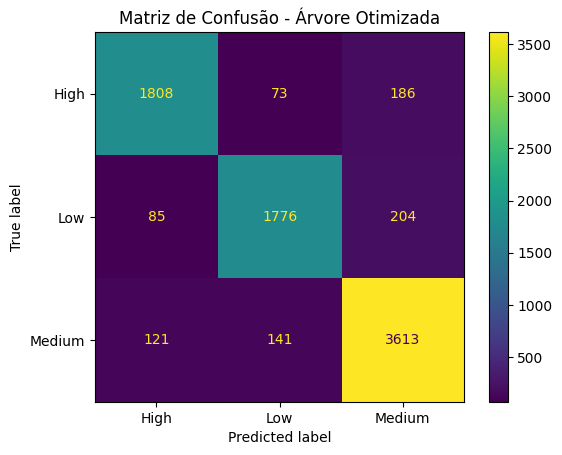

In [20]:
y_pred = grid_dtc.best_estimator_.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Matriz de Confusão - Árvore Otimizada')
plt.show()

### Análise da Matriz de Confusão

A diagonal principal representa os acertos, mostrando boa performance nas três classes. O erro mais frequente do modelo é classificar jogadores `Low` como `Medium`, o que pode estar relacionado ao leve desbalanceamento do target, já que Medium é a classe majoritária. A classe `High` tende a ser a mais bem classificada entre as três.

## Exportação do modelo

O melhor modelo (Árvore de Classificação otimizada) é exportado em arquivo `.pkl` para ser carregado na aplicação full stack. O `StandardScaler` já está embutido no pipeline exportado, portanto não é necessário salvar um arquivo separado para o scaler.


In [21]:
with open('modelo.pkl', 'wb') as f:
    pickle.dump(grid_dtc.best_estimator_, f)

print('Modelo exportado: modelo.pkl')


Modelo exportado: modelo.pkl


## Análise de Resultados e Conclusão

O objetivo deste projeto foi treinar modelos de classificação para prever o nível de engajamento (High, Medium ou Low) de jogadores online, utilizando dados demográficos e métricas de jogo.

Foram treinados 4 modelos: KNN, Árvore de Classificação, Naive Bayes e SVM. Todos superaram o baseline de ~48% (que seria chutar sempre "Medium"), o que indica que as features do dataset têm relação com o nível de engajamento.

Após a otimização de hiperparâmetros com GridSearchCV (cv=5), o modelo que apresentou melhor desempenho foi a Árvore de Classificação. A otimização teve maior impacto nesse modelo porque limitar a profundidade da árvore evitou overfitting — sem esse limite, a árvore "decora" os dados de treino e generaliza mal.

Um ponto interessante foi que a Árvore ultrapassou o SVM após a otimização, apesar do SVM ter sido superior com parâmetros padrão. Outro destaque é que o KNN teve dificuldade consistente com a classe Low, mesmo após otimização.

Como pontos de atenção, destaco:
- O target apresenta leve desbalanceamento (~48% Medium vs ~26% High e Low), o que pode favorecer predições para a classe Medium
- O SVM teve custo computacional significativamente maior que os demais modelos, especialmente na etapa de otimização

O modelo escolhido para exportação e integração na aplicação full stack foi a Árvore de Classificação otimizada. A matriz de confusão confirma que o principal erro do modelo é classificar jogadores Low como Medium, coerente com o desbalanceamento observado no target.

## Reflexão sobre Segurança

O item 6 dos requisitos pede uma reflexão sobre como boas práticas de Desenvolvimento de Software Seguro poderiam ser aplicadas a este problema. A seguir, são discutidas as principais considerações.

### Anonimização e minimização de dados

O dataset contém atributos demográficos como `Age`, `Gender` e `Location`, que podem ser considerados dados pessoais dependendo do contexto de coleta. Boas práticas incluem:

- **Anonimização**: substituir identificadores diretos (como `PlayerID`) por identificadores artificiais sem relação com o indivíduo real — já feito neste projeto, pois `PlayerID` foi removido antes da modelagem.
- **Generalização**: em vez de usar a idade exata, agrupar em faixas etárias (ex: 15–24, 25–34) para reduzir o risco de reidentificação.
- **Minimização**: coletar e reter apenas os atributos estritamente necessários para a predição. Caso `Gender` ou `Location` não contribuíssem significativamente para o modelo, deveriam ser removidos.

### Validação de entrada

A API do backend valida todos os campos antes de alimentar o modelo — tipos, ranges numéricos e valores categóricos permitidos. Isso evita tanto erros de execução quanto ataques de injeção de dados malformados.

### Controle de acesso e CORS

O backend restringe as origens permitidas via CORS, aceitando requisições apenas de `localhost:5000` e `localhost:8000` durante o desenvolvimento. Em produção, essa lista deveria ser restrita ao domínio real da aplicação.

### Proteção do modelo

O arquivo `modelo.pkl` é carregado diretamente no backend e nunca exposto ao frontend. Isso impede que o modelo seja extraído e usado para ataques adversariais (entradas cuidadosamente construídas para enganar o classificador).

### Consideração sobre viés

Modelos treinados com dados demográficos podem aprender vieses presentes nos dados históricos. Uma boa prática é auditar o desempenho do modelo por subgrupos (ex: acurácia por gênero ou localização) para garantir que não há discriminação sistemática nas predições.
